# 🚀 Welcome to the Data Visualization Exercise! 🎶🎞 ✨

## Background
Netflix, originally founded in 1997 as a DVD rental service, has evolved into the world's leading entertainment and media company by market capitalization. As of January 2021, it serves over 200 million subscribers globally.

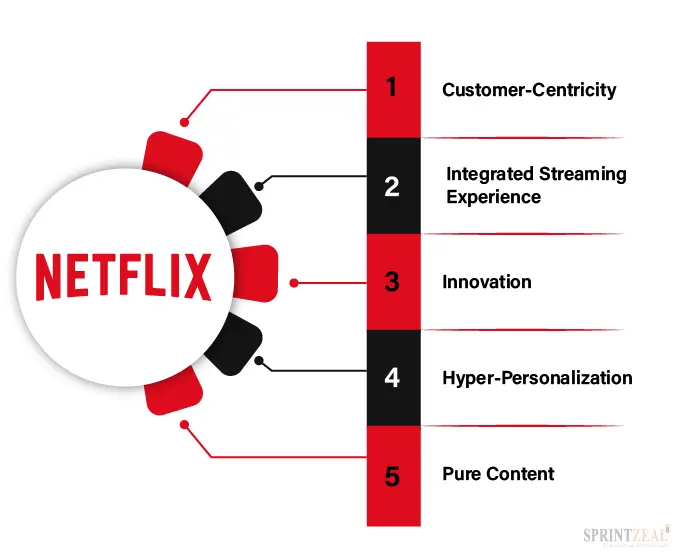

## Instructions
In this exercise, we will utilize a Netflix dataset to explore the following cases through various visualizations such as plots, bar charts, and scatter plots, as covered in the course:

1. Preprocess the dataset by handling any missing values before starting the analysis.
2. Visualize and analyze movie duration by year of release.
3. Visualize the number of movies directed by each director annually.
4. Visualize the types of movies produced by each director annually.
5. Visualize the distribution of movie genres (e.g., Drama, Horror, Action) by country.
6. Visualize the top three genres of movies released between 2017 and 2021.
7. Visualize the top 10 countries producing Netflix content.
8. Visualize the top 10 directors producing TV shows on Netflix from 2010 to 2020.
9. Visualize the monthly addition of new content to Netflix.
10. Filter the dataset to keep only movies with a duration under 60 minutes.
11. Visualize movie titles by genre within the filtered dataset.
12. Apply a heatmap to the dataset and draw relevant conclusions based on the visualization.


## Guidelines
You may use concepts introduced in previous courses if necessary.
Employ various types of visualizations (e.g., bar charts, box plots, line plots, histograms) and select the most appropriate method for each case.


Goodluck 😇


Creating a scatter plot

In [21]:
import pandas as pd


netflix = pd.read_csv("Datasets/netflix_data.csv")
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas


In [22]:
netflix

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...",Sweden,"October 19, 2020",2005,99,When Lebanon's Civil War deprives Zozo of his ...,Dramas
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,111,A scrappy but poor boy worms his way into a ty...,Dramas
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,44,"In this documentary, South African rapper Nast...",Documentaries
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,1,Dessert wizard Adriano Zumbo looks for the nex...,International TV


In [23]:
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
duration           0
description        0
genre              0
dtype: int64

In [24]:
netflix.shape

(7787, 11)

## KNN Imputation of Missing Values
---

In [25]:
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

nan_cols = ['director', 'cast', 'country', 'date_added']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)

netflix_encoded = netflix.copy()
netflix_encoded[nan_cols] = encoder.fit_transform(netflix[nan_cols])

knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')
netflix_imputed_values = knn_imputer.fit_transform(netflix_encoded[nan_cols])

netflix_encoded[nan_cols] = np.round(netflix_imputed_values)
netflix[nan_cols] = encoder.inverse_transform(netflix_encoded[nan_cols])

print(netflix[nan_cols].isnull().sum())

netflix.head()

director      0
cast          0
country       0
date_added    0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,Eric Notarnicola,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas


In [26]:
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
duration        0
description     0
genre           0
dtype: int64

## Movie Duration by Year of Release

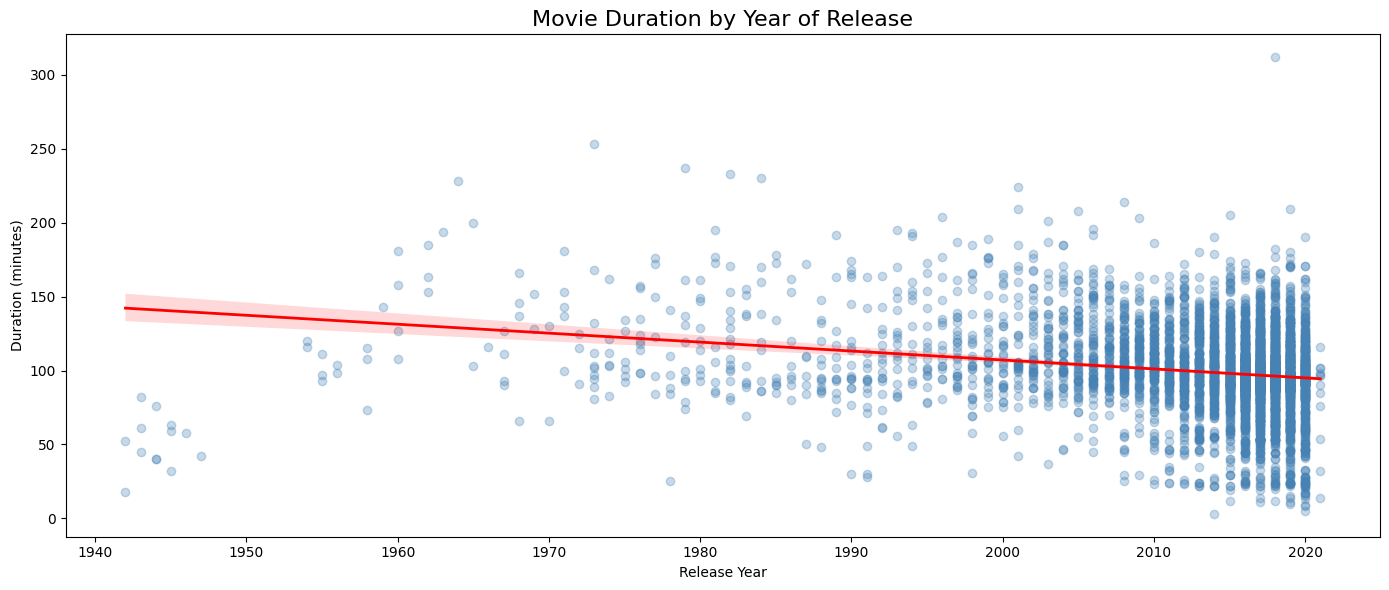

release_year
2012    100.620253
2013     98.752475
2014    100.266393
2015     99.827225
2016     95.112150
2017     94.836022
2018     96.170300
2019     93.457045
2020     89.795620
2021     80.166667
Name: duration_min, dtype: float64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter movies only and extract numeric duration
movies = netflix[netflix['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration']

# Plot: scatter + trend line
plt.figure(figsize=(14, 6))
sns.regplot(
    data=movies,
    x='release_year',
    y='duration_min',
    scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Movie Duration by Year of Release', fontsize=16)
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

# Summary stats per year
print(movies.groupby('release_year')['duration_min'].mean().tail(10))

## Movies per Director per Year (Heatmap)

In [29]:
movies_dir = netflix[netflix['type'] == 'Movie'].copy()
movies_dir = movies_dir.dropna(subset=['director'])

director_year = (
    movies_dir.groupby(['director', 'release_year'])
    .size()
    .reset_index(name='movie_count')
)

top_directors = (
    movies_dir['director']
    .value_counts()
    .head(10)
    .index
)

director_year_top = director_year[director_year['director'].isin(top_directors)]

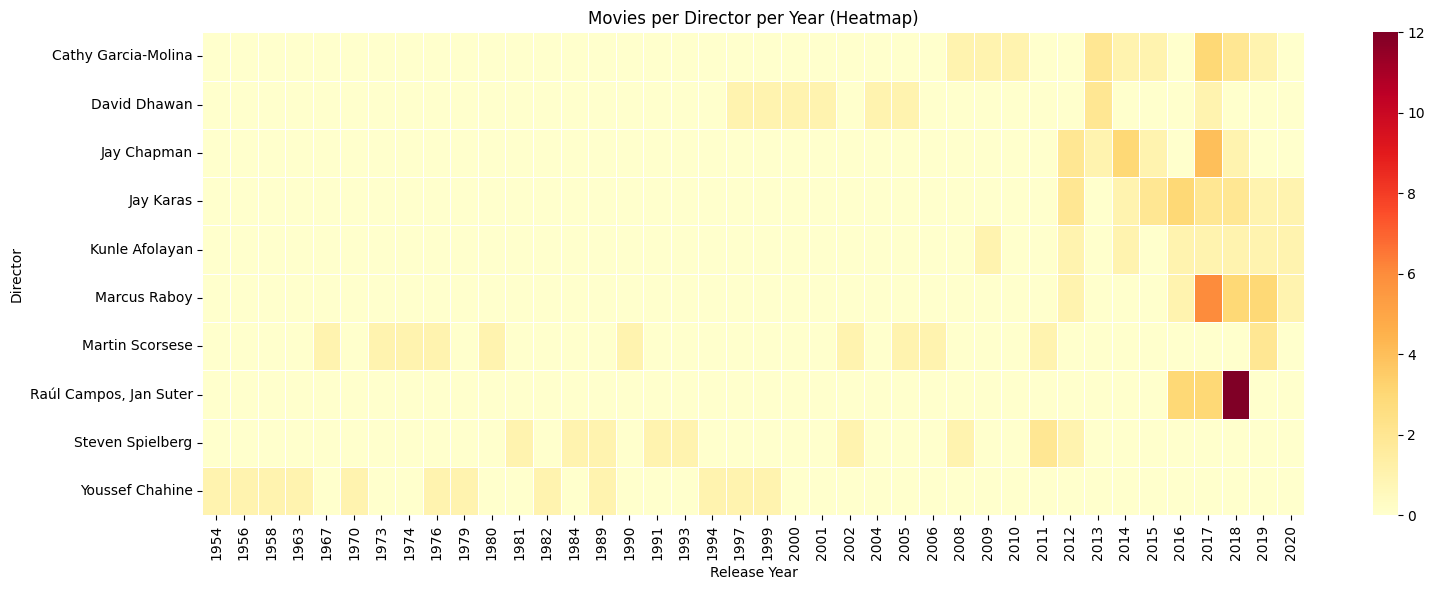

In [ ]:
pivot = director_year_top.pivot(index='director', columns='release_year', values='movie_count').fillna(0)


plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Movies per Director per Year (Heatmap)')
plt.xlabel('Release Year')
plt.ylabel('Director')
plt.tight_layout()
plt.show()


## Movie Types Produced by Each Director Annually

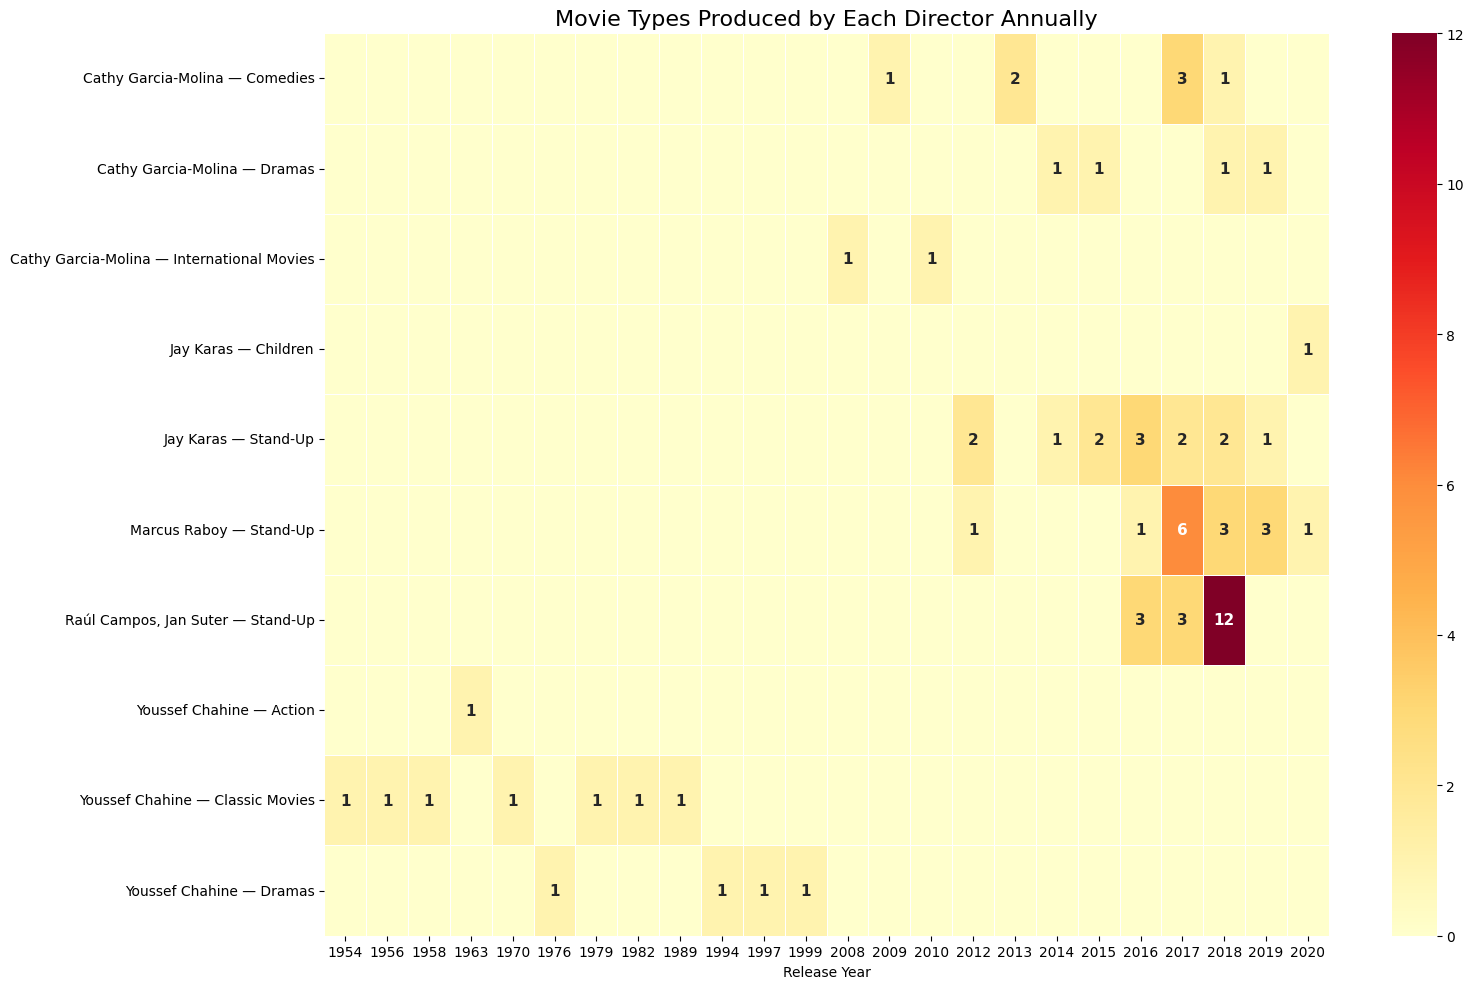

In [45]:
# Filter movies
movies_genre = netflix[netflix['type'] == 'Movie'].copy()

# Count movies per director, genre, year
director_genre_year = (
    movies_genre.groupby(['director', 'release_year', 'genre'])
    .size()
    .reset_index(name = 'movie_count')
)

# Focus on top 5 directors
top5_directors = (
    movies_genre['director']
    .value_counts()
    .head(5)
    .index
)

data_top5 = director_genre_year[director_genre_year['director'].isin(top5_directors)]

# Plot: Heatmap, director+genre on y-axis, year on x-axis
data_top5['director_genre'] = data_top5['director'] + ' — ' + data_top5['genre']

pivot = data_top5.pivot_table(
    index='director_genre',
    columns='release_year',
    values='movie_count',
    fill_value=0
)

annot_labels = np.where(pivot > 0, pivot.astype(int).astype(str), '')

plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot,
    cmap ='YlOrRd',
    linewidth = 0.5,
    annot=annot_labels,
    fmt='',
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title('Movie Types Produced by Each Director Annually', fontsize=16)
plt.xlabel('Release Year')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Distribution of Movie Genres by Country

## Top 3 Genres of Movies released between 2017 and 2021

## Top 10 Countries Producing Netflix Content

## Top 10 Directors producing TV shows on Netflix from 2010 to 2020

## Monthly Addition of new content on Netflix

## Movie Titles by Genre <60 minutes

## Heatmap